In [1]:
import torch
import numpy as np
import scipy
import pytorch_lightning as pl
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
torch.set_float32_matmul_precision('medium')
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

import multiprocessing
# multiprocessing.set_start_method('spawn')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os, sys

sys.path.append("../../mist-base")
sys.path.append('../../')

from src.simulators.fd_simulators import GW_Additive_F, GW_Additive_F_Correlated
from simulators.utils import *
from utils.data import OnTheFlyDataModule, StoredDataModule
from utils.module import CustomLossModule_withBounds, BCELossModule, NewLossModule_withBounds
from models.online_norm import OnlineStandardizingLayer
from models.resnet_1d import ResidualNet

import plotfancy as pf
pf.housestyle_rcparams()

mycolors = ['#570f6d', '#bb3754', '#f98e08']
quantiles = np.array([0.05199686, 0.2145543,  0.58780088, 1.17737921, 1.91882754,
 2.75067576, 3.63463655])/np.sqrt(2)

quantiles_long = np.array([7.11978022e-04, 7.96148769e-03, 5.19968566e-02, 2.14554300e-01,
 5.87800876e-01, 1.17737921e+00, 1.91882754e+00, 2.75067576e+00,
 3.63463655e+00, 4.55164698e+00, 5.49045819e+00])/np.sqrt(2)

netid = 'GW_complex'


In [3]:
simulator_blank = GW_Additive_F(bkg=True, fraction=0.0002)
Nbins=simulator_blank.Nbins
del simulator_blank

In [4]:
class Network_epsilon_complex(torch.nn.Module):
    def __init__(self, nbins):
        super().__init__()
        
        self.nbins = nbins
        self.logvariance = torch.nn.Parameter(torch.ones(self.nbins, dtype=torch.float64) * 5)
        
        self.net = ResidualNet(2, 2, hidden_features=128, num_blocks=2, kernel_size=1, padding=0) #now takes 2 input channels (real, imag) and outputs 1 (real epsilon)
        self.mu_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.nbins * 2, 128), # Input is concatenated real and imaginary parts
            torch.nn.ReLU(),
            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, self.nbins * 2)  # Output is concatenated real and imaginary parts
        )

    def mu(self, x):
        x_real_imag = torch.cat([x.real, x.imag], dim=-1) # Shape: [B, 2 * nbins]
        out_real_imag = self.mu_predictor(x_real_imag) # Shape: [B, 2 * nbins]
        pred_real, pred_imag = torch.chunk(out_real_imag, 2, dim=-1) # Each is [B, nbins]
        return torch.complex(pred_real, pred_imag)
 
    
    def epsilon(self, x):
        resd = x - self.mu(x)
        resd_channels = torch.stack([resd.real, resd.imag], dim=1)
        out_channels = self.net(resd_channels)
        return torch.complex(out_channels[:, 0, :], out_channels[:, 1, :])
    
    def snr(self, x):
        return torch.abs(self.epsilon(x)) / self.logvariance.exp().sqrt()  # [B, N_bins]
    
    def bounds(self):
        return self.logvariance.detach().exp().sqrt().mean(-1) * 5
        
    def forward(self, x):
        
        x0_block = torch.nan_to_num(x['x0'], nan=0, posinf=0, neginf=0) # Expected to be complex
        mu_block = torch.nan_to_num(x['mu'], nan=0, posinf=0, neginf=0) # Expected to be complex
        ni = torch.nan_to_num(x['ni'], nan=0, posinf=0, neginf=0)
        
        rand_real = 2 * torch.rand(x0_block.shape, device=x0_block.device) - 1
        rand_imag = 2 * torch.rand(x0_block.shape, device=x0_block.device) - 1
        epsilon_sim_unit = torch.complex(rand_real, rand_imag)
        epsilon_sim = self.bounds()*epsilon_sim_unit*ni

        data = x0_block + epsilon_sim # data is complex
        
        # net evaluation_m
        net_mu = self.mu(data) # net_mu is complex
        
        # Loss for complex numbers is the squared magnitude of the difference
        error_mu = (torch.abs(net_mu - mu_block))**2
        
        l_mu = error_mu / (self.logvariance.exp() + 1e-10) + self.logvariance
        l_mu_return = l_mu.sum() * 0.5

        # net evaluation_e
        net_epsilon = self.epsilon(data) # net_epsilon is real
        mask = ( ni != 0 )
        
        # epsilon_sim is real, net_epsilon is real. Standard squared error.
        squared_error_e = (torch.abs(net_epsilon - epsilon_sim))**2                                     # [B, N_bins]
        l_e = squared_error_e / (self.logvariance.exp() + 1e-21) + self.logvariance               # [B, N_bins]
        l_e_return = (l_e * mask.float()).sum() * 0.5
        
        # combine
        return l_mu_return + l_e_return


In [5]:

network_epsilon = Network_epsilon_complex(Nbins)
checkpoint = torch.load(f'networks/network_{netid}', 
                        weights_only=False,map_location=torch.device('cpu'))
sd = checkpoint.state_dict()
new_state_dict = {}
for key in sd:
    new_key = key.replace('model.', '')  # Remove 'model.' prefix
    new_state_dict[new_key] = sd[key]
    
network_epsilon.load_state_dict(new_state_dict)
network_epsilon.cuda().double().eval()

model = CustomLossModule_withBounds(network_epsilon, learning_rate=3e-3)
checkpoint = torch.load(f'networks/model_{netid}', 
                        weights_only=False,map_location=torch.device('cpu'))
sd = checkpoint.state_dict()
for key in sd:
    new_key = key.replace('model.', '')  # Remove 'model.' prefix
    new_state_dict[new_key] = sd[key]
    
model.load_state_dict(sd)
network_epsilon.cuda().double().eval()
network_epsilon.cuda()


Network_epsilon_complex(
  (net): ResidualNet(
    (initial_layer): Conv1d(2, 128, kernel_size=(1,), stride=(1,))
    (blocks): ModuleList(
      (0-1): 2 x ResidualBlock(
        (conv_layers): ModuleList(
          (0-1): 2 x Conv1d(128, 128, kernel_size=(1,), stride=(1,))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Conv1d(128, 2, kernel_size=(1,), stride=(1,))
  )
  (mu_predictor): Sequential(
    (0): Linear(in_features=8194, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8194, bias=True)
  )
)

In [6]:
simulator = GW_Additive_F(bkg=True, fraction=0.0002)

In [7]:
N_mc = 5e5

batch_size = 2**8
N_batch = int(N_mc / batch_size)

ts_bin_H0_epsilon = []
for _ in tqdm(range(N_batch)):
    mc_samples = simulator.sample(batch_size)
    cleaned = torch.nan_to_num(mc_samples['x0'], nan=0)
    ts_batch =  (network_epsilon.snr(cleaned.cuda())**2).detach().cpu().numpy()
    ts_bin_H0_epsilon.append(ts_batch)
    
ts_bin_H0_epsilon = np.concatenate(ts_bin_H0_epsilon)

ts_sum_H0_epsilon = ts_bin_H0_epsilon.sum(axis=1)
ts_sum_H0_epsilon_mean = ts_sum_H0_epsilon.mean()
ts_sum_H0_epsilon = ts_sum_H0_epsilon - ts_sum_H0_epsilon_mean

  0%|          | 0/1953 [00:00<?, ?it/s]

100%|██████████| 1953/1953 [13:13<00:00,  2.46it/s]


In [8]:
def chop_middle(array, remove=5, linemode=True):
    if len(array)%2==0:
        mid_u = int(len(array)/4)
        mid_d = mid_u -1
        if not linemode:
            return np.concatenate([array[:mid_d-remove], array[mid_u+remove:]])
        else:
            return array[:mid_d-remove] , array[mid_u+remove:], array[mid_u]
    else:
        mid = len(array)//2
        if not linemode:
            return np.concatenate([array[:mid-remove], array[mid+remove:]])
        else:
            return array[:mid-remove], array[mid+remove:], array[mid]
        
def get_snr2(input:dict):
    target = input['x']
    snr2_nn = network_epsilon.snr(target.cuda()).detach().cpu().numpy()**2 
    return snr2_nn

def local_do_ticks(list_of_axes, dir = 'in'):
    for ax in list_of_axes:
        ax.minorticks_on()
        ax.tick_params(top=True,right=True, direction=dir, length=7, which='major')
        ax.tick_params(top=True,right=True, direction=dir, length=4, which='minor')

def local_fix_frame(ax):
    ax.tick_params(color='black', labelcolor='black')
    ax.spines[:].set_color('black')
    ax.spines[:].set_linewidth(1)
    return True

def local_fix_plot(a, tickdir ='in'):
    for axes in a:
        axes.grid(False)
        local_do_ticks([axes], tickdir)
        local_fix_frame(axes)
    return True

def t_to_pvalue_empirical_vec(ts_obs, ts0_ref):
    counts = np.sum(ts0_ref >= ts_obs, axis=0)
    return (counts + 1) / (ts0_ref.shape[0] + 1)

def get_p_nn_vec(ts_bin_obs):
    m = ts_bin_H0_epsilon.mean(axis=0)
    ts0_ref = ts_bin_H0_epsilon - m
    ts_obs = ts_bin_obs - m
    return t_to_pvalue_empirical_vec(ts_obs, ts0_ref)

def get_stats(inputdata: torch.Tensor):
    # INPUT DATA NEEDS TO BE OF SHAPE NBIN
    to_nn = {'x':inputdata.unsqueeze(0)}
    tbin = get_snr2(to_nn).squeeze(0)
    pbin = get_p_nn_vec(tbin)
    return tbin, pbin

def pvalue_grid_eps(dat):
    eps_t_mean = np.mean(ts_bin_H0_epsilon, axis=0)
    eps_t_ref = ts_bin_H0_epsilon - eps_t_mean
    counts = np.sum(eps_t_ref >= dat[:, np.newaxis, :], axis=1)
    return (counts + 1) / (len(eps_t_ref) + 1)

def pvalue_grid_BCE(dat):
    BCE_t_mean = np.mean(ts_bin_H0_BCE, axis=0)
    BCE_t_ref = ts_bin_H0_BCE - BCE_t_mean
    counts = np.sum(BCE_t_ref >= dat[:, np.newaxis, :], axis=1)
    return (counts + 1) / (len(BCE_t_ref) + 1)

def pvalue_grid_eps_looped(dat):
    eps_t_mean = np.mean(ts_bin_H0_epsilon, axis=0)
    eps_t_ref = ts_bin_H0_epsilon - eps_t_mean
    counts = np.zeros_like(dat, dtype=int)
    for i in range(dat.shape[0]):
        counts[i, :] = np.sum(eps_t_ref >= dat[i, :], axis=0)
    return (counts + 1) / (len(eps_t_ref) + 1)

In [32]:
def noemi_plot(Inputdata:torch.Tensor,f=simulator.frequencies, ni=None, plotname=None): 
    sampling = type(ni) != type(None)

    # DATA MANAGEMENT #
    realinput=torch.abs(Inputdata)
    tstat, pstat = get_stats(Inputdata)
    nimask = ni.to(dtype=torch.bool) if sampling else None 

    # PLOT SETUP #
    
    fig, ax1 = pf.create_plot(size=(6,2))
    plt.setp(ax1.get_xticklabels(),visible=False)
    ax1.set_ylabel(r'$\tilde{d}_w(f)$')
    ax1.set_xlim(20,500)
    ax1.set_ylim(-3,3)

    ax1_hist = fig.add_axes((1,0,0.3,1), sharey=ax1)
    plt.setp(ax1_hist.get_xticklabels(),visible=False)
    plt.setp(ax1_hist.get_yticklabels(),visible=False)


    ax2 = fig.add_axes((0,-1,1,1), sharex=ax1)
    plt.setp(ax2.get_xticklabels(),visible=False)
    ax2.set_ylabel(r'$\mathrm{SNR}^2(f)$')
    ax2.set_ylim(-1,29)

    ax3 = fig.add_axes((0,-2,1,1), sharex=ax1)
    ax3.set_xlabel(r'$f$ [Hz]')
    ax3.set_ylabel(r'$\mathrm{p}_i$')
    ax3.set_ylim(9e-6, 5)

    ax4 = fig.add_axes((1.15,-2,.8*1/2,.8*3/2))
    ax4.set_xlabel(r'$\mathrm{t}_{\mathrm{sum}}|H_0$')
    ax4.set_ylabel('Density')
    ax4.set_xlim(-840,840)
    ax4.set_yticks([])
    # ax4.set_ylim(-0.06,1.3)

    axes=[ax1,ax1_hist,ax2,ax3,ax4]

    # TOP AXIS #
    # for i in range(6):
    #     ax1.fill_between(f, quantiles_long[-i], quantiles_long[i], color='#77aca2', alpha=0.1,zorder=-1)
    #     ax1_hist.fill_between(f, quantiles_long[-i], quantiles_long[i], color='#77aca2', alpha=0.1,zorder=-1)  

    colors = [mycolors[0], "#f55b0d"]
    labels = [r'$\mathtt{Re}[\tilde{d}_w(f)]$', r'$\mathtt{Im}[\tilde{d}_w(f)]$']

    if sampling:
        for i,d in enumerate([Inputdata.real, Inputdata.imag]):
            ax1.plot(f, d, color=colors[i], linewidth=1, label=labels[i], alpha=0.8)
            ax1.scatter(f[nimask], d[nimask], color='k', s=10, label=(r'$X|H_i$' if i==0 else None), zorder=10)
            ax1_hist.hist(d[~nimask], bins=np.linspace(-4,4,30), color=colors[i], density=True, orientation='horizontal', alpha=0.8)
            ax1_hist.hist(d[~nimask], bins=np.linspace(-4,4,30), color="k",histtype='step', density=True, orientation='horizontal')    

        ax1.vlines(f[nimask], -1000,1000, color="#838383", zorder=-10)
        ax2.vlines(f[nimask], -1000,1000, color="#838383", zorder=-10)
        ax3.vlines(f[nimask], 0,10, color="#838383", zorder=-10)

    else:
        for i,d in enumerate([Inputdata.real, Inputdata.imag]):
            ax1.plot(f, d, color=colors[i], linewidth=1, label=labels[i], alpha=0.8)
            ax1_hist.hist(d, bins=np.linspace(-4,4,30), color=colors[i], density=True, orientation='horizontal', alpha=0.8)
            ax1_hist.hist(d, bins=np.linspace(-4,4,30), color="k",histtype='step', density=True, orientation='horizontal')           

    ax1.legend(fontsize=11)
    # T STATISTIC AXIS #

    ax2.plot(f,tstat, color='#ff004f', lw=1)

    # PVALUE AXIS #

    ax3.semilogy(f, pstat, color='#ff004f', lw=1)

    # TSUM AXIS #

    ax4.hist(ts_sum_H0_epsilon,bins=np.linspace(-1000,1000,50), color='#ff004f', density=True, orientation='vertical')
    ax4.hist(ts_sum_H0_epsilon,bins=np.linspace(-1000,1000,50), color='k', density=True, histtype='step',orientation='vertical')

    pf.fix_plot(axes)

    if not type(plotname) == type(None):
        plt.tight_layout()
        plt.savefig(f'figs/{netid}/{plotname}.png', dpi=700, bbox_inches = 'tight')

    plt.show()

In [26]:
### DATA FOR PLOTTING ###
test = simulator.sample(1)
null = torch.nan_to_num(test['x0'][0], nan=0)
alternate = torch.nan_to_num(test['xi'][0], nan=0)
NI = test['ni'][0]
gw150914 = torch.nan_to_num(torch.from_numpy(simulator.get_GW150914_fd()), nan=0)


/tmp/ipykernel_626632/2103342793.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


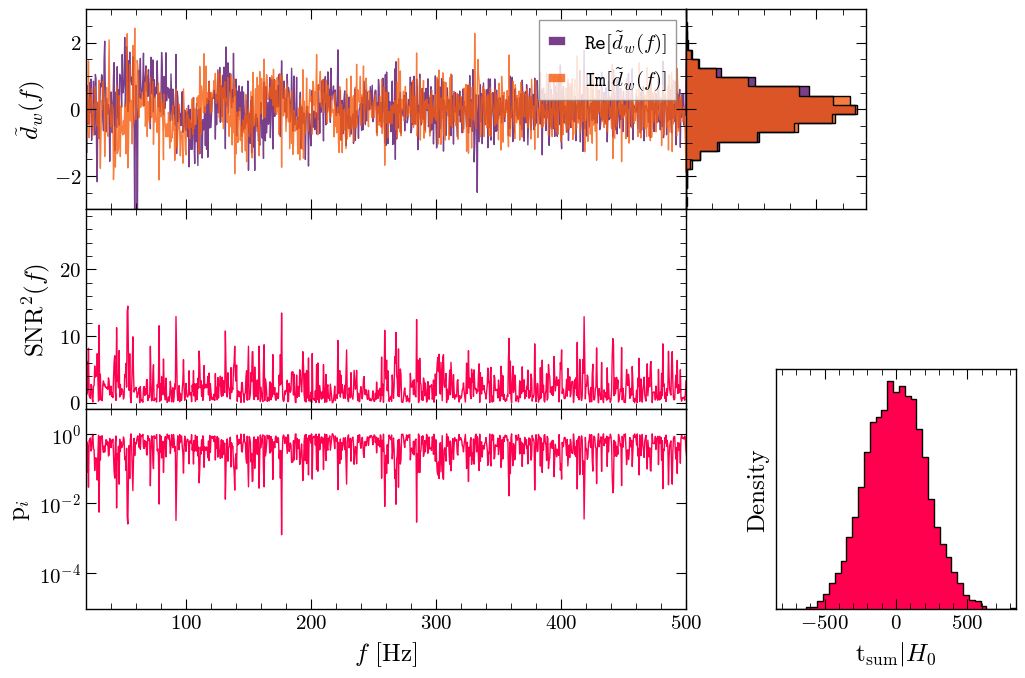

In [29]:
noemi_plot(null, plotname='null')

/tmp/ipykernel_626632/2684211202.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


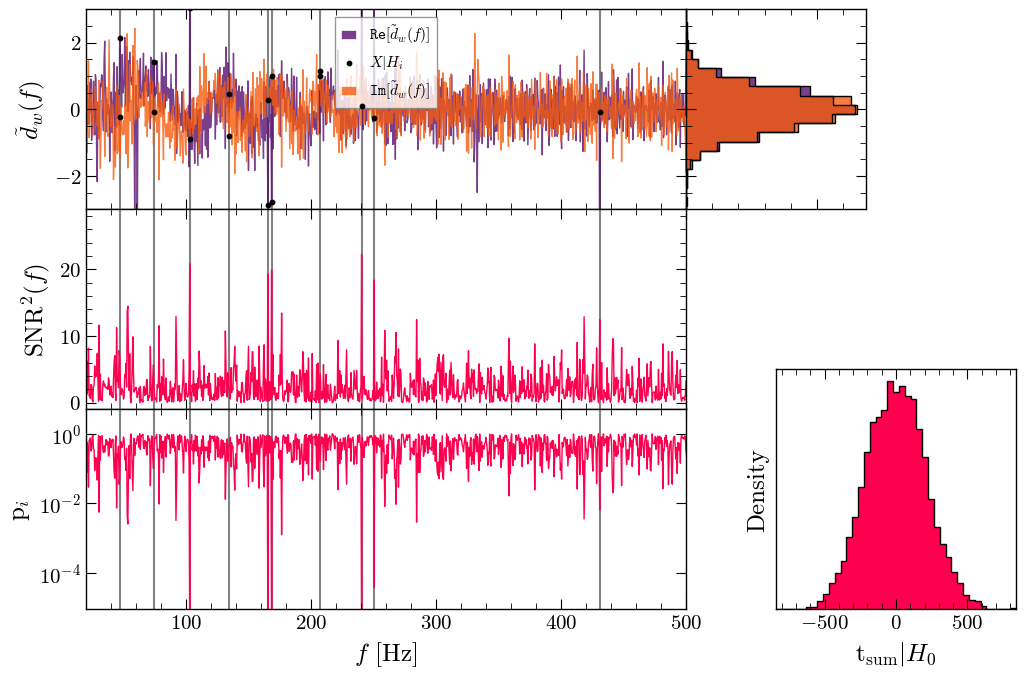

In [33]:
noemi_plot(alternate, ni=NI, plotname='alternative')

/tmp/ipykernel_626632/2103342793.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


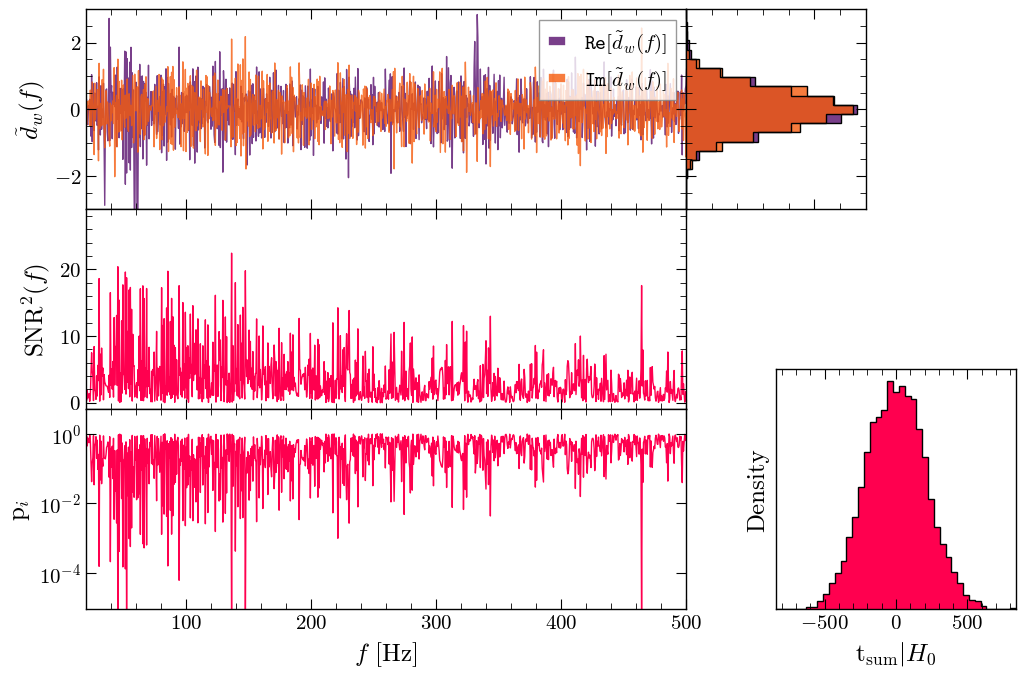

In [31]:
noemi_plot(gw150914, plotname='gw150914')